# strawveri - BTK Datathon 2026: career_success_score tahmini

Öğrencilerin kariyer başarı puanını (0-100 arası) tahmin eden çözümümüzü uçtan uca anlatıyoruz. Veri karışık tipte. Bir yanda tablo halinde özellikler var, diğer yanda kuralların zorunlu tuttuğu bir Türkçe mentör değerlendirme metni (`mentor_feedback_text`). Başarı MSE ile ölçülüyor. Takım olarak ikiyiz: Furkan ADIKTI ve İrem SARGIN.

Aşağıda veriyi nasıl anladığımızı, her bileşeni neden kurduğumuzu, sonucu nasıl doğruladığımızı ve neyi deneyip neden bıraktığımızı sırayla göreceksiniz. Hafif hücreler (özellik üretimi, TF-IDF, ağaç toplulukları, meta, kuyruk ve harman) doğrudan burada koşuyor ve grafiklerini üretiyor. Ağır bileşenleri (LoRA, embedding modelleri, TabPFN, SetFit, TAPT) ayrı bir GPU'da çalıştırdık; kodlarını burada gösteriyoruz, çıktıları ise hazır skor olarak modele giriyor.

Bölümler şöyle ilerliyor: 1-7 keşifsel analiz, 8 özellik üretimi, 9 metin işleme, 10 temel modeller, 11 meta birleştirme, 12 kuyruk kalibrasyonu, 13 final, 14 doğrulama, 15 denedik ama bıraktık, 16 sonuç.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os, re, time, warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"]=(9,3.2); plt.rcParams["axes.grid"]=True
DATA=next((p for p in ["/kaggle/input/datathon-2026","/kaggle/input/competitions/datathon-2026","data"] if os.path.exists(f"{p}/train.csv")),"data")
train=pd.read_csv(f"{DATA}/train.csv"); test=pd.read_csv(f"{DATA}/test_x.csv")
TGT="career_success_score"; y=train[TGT].to_numpy(float)
print("train:",train.shape,"| test:",test.shape)

train: (10000, 47) | test: (10000, 46)


## 1-7. Keşifsel veri analizi

Her bulguyu bir modelleme kararına bağladık.

| # | Bulgu | Karar |
|---|---|---|
| 1 | 10k satır, 47 kolon; 40 sayısal, 7 kategorik/metin; student_id bir kimlik | id kullanılmaz, metin dahil edilir |
| 2 | Hedef [0,100], %7.7 tam-100 (tavan kütlesi), 2 ondalık (sentetik) | iki-aşamalı kuyruk kalibrasyonu |
| 3 | Yıl-heteroskedastisitesi: std 12.6 (2019) -> 18.3 (2025), tavan %3.7 -> %13; test'in %62'si 2024-26 | yıl-ağırlıklı CV, sığ ağaç |
| 4 | MNAR eksiklik: github eksikse hedef -2.2 | eksiklik-bayrağı + örüntüsü |
| 5 | project_quality baskın (r=0.54); lineer R2 0.57, ensemble 0.67 | etkileşim özellikleri + ağaçlar |
| 6 | Metin: 10k distinct, 0 train/test ortak, r~0.61 (en güçlü tekil) | zengin NLP yığını |
| 7 | Kategorik alanlar zayıf, tekrar eden satır yok | sızıntı veya ezber işareti yok |

Aşağıdaki hücreler bu bulguları grafikle üretir.

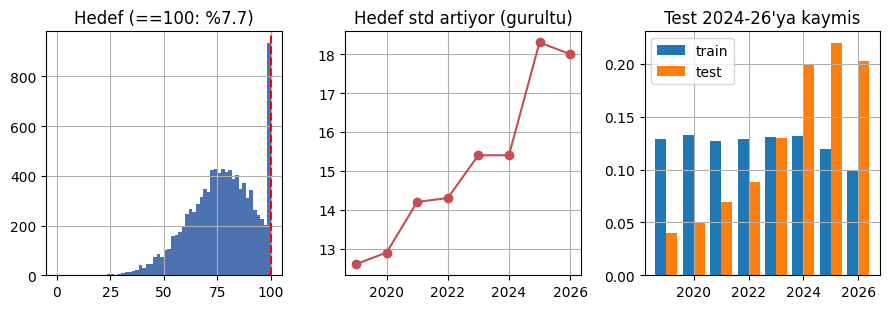

,train_n,test_n,y_std,ceil_%
application_year,,,,
2019,1289,403,12.6,3.7
2020,1329,507,12.9,3.8
2021,1270,691,14.2,6.4
2022,1293,881,14.3,7.6
2023,1312,1298,15.4,8.1
2024,1319,1994,15.4,9.2
2025,1191,2197,18.3,13.0
2026,997,2029,18.0,11.3


In [2]:
g=train.groupby("application_year")[TGT]
tab=pd.DataFrame({"train_n":train["application_year"].value_counts().sort_index(),
  "test_n":test["application_year"].value_counts().sort_index(),
  "y_std":g.std().round(1),"ceil_%":(g.apply(lambda s:100*(s>=99.999).mean())).round(1)})
fig,ax=plt.subplots(1,3)
ax[0].hist(y,bins=60,color="#4C72B0"); ax[0].axvline(100,color="r",ls="--"); ax[0].set_title(f"Hedef (==100: %{100*(y>=99.999).mean():.1f})")
ax[1].plot(tab.index,tab["y_std"],"o-",color="#C44E52"); ax[1].set_title("Hedef std artiyor (gurultu)")
ax[2].bar(tab.index-0.2,train["application_year"].value_counts(normalize=True).sort_index(),0.4,label="train")
ax[2].bar(tab.index+0.2,test["application_year"].value_counts(normalize=True).sort_index(),0.4,label="test")
ax[2].set_title("Test 2024-26'ya kaymis"); ax[2].legend(); plt.tight_layout(); plt.show()
display(tab)

In [3]:
num=train.select_dtypes("number").columns
cc=train[num].corrwith(train[TGT]).drop(TGT).abs().sort_values(ascending=False)
print("En guclu 6 sayisal iliski:"); print(cc.head(6).round(3).to_string())
print("\nMNAR eksiklik (eksik y - dolu y):")
for c in ["github_avg_stars","portfolio_score","english_exam_score"]:
    m=train[c].isna(); print(f"  {c}: {y[m].mean()-y[~m].mean():+.1f}")
t=train["mentor_feedback_text"].fillna("")
print(f"\nMetin: {t.nunique()}/{len(t)} distinct | test ile ortak: {len(set(t)&set(test['mentor_feedback_text'].fillna('')))} | zit-yapi %{100*t.str.contains(r'ancak|ama|fakat').mean():.0f}")

En guclu 6 sayisal iliski:
project_quality_score        0.541
technical_interview_score    0.340
problem_solving_score        0.290
cloud_score                  0.277
coding_score                 0.274
devops_score                 0.272

MNAR eksiklik (eksik y - dolu y):
  github_avg_stars: -2.2
  portfolio_score: -1.4
  english_exam_score: -1.0



Metin: 10000/10000 distinct | test ile ortak: 0 | zit-yapi %35


## 7.5 Detaylı görselleştirmeler

Aşağıdaki grafikler EDA bulgularını görselleştirir.

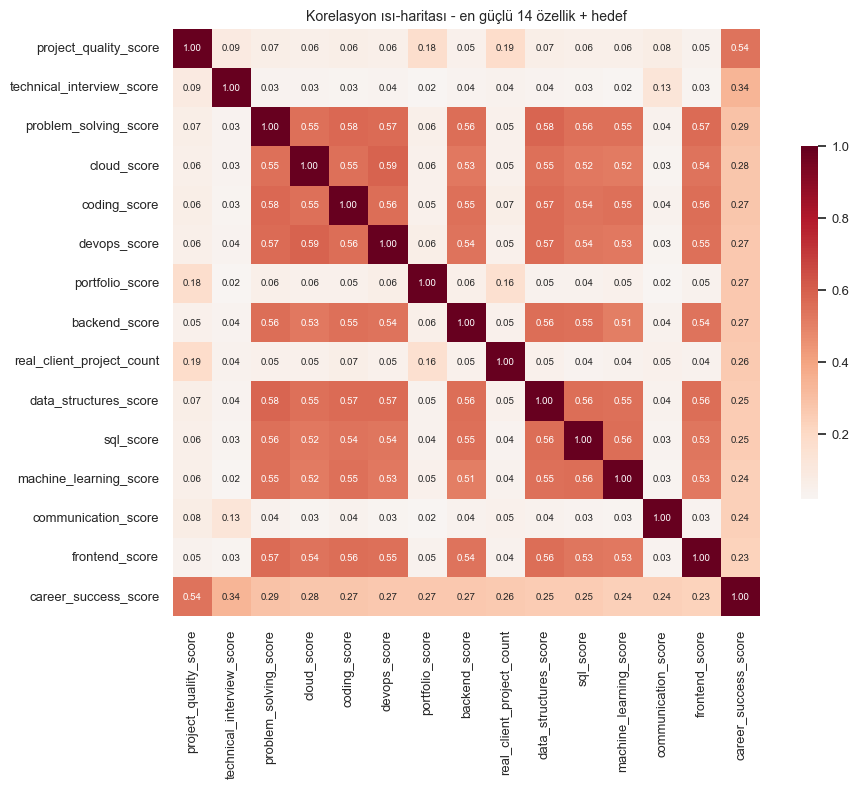

In [4]:
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=0.85)
vnum=[c for c in train.select_dtypes("number").columns if c!=TGT]
topf=train[vnum+[TGT]].corr()[TGT].drop(TGT).abs().sort_values(ascending=False).head(14).index.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(train[topf+[TGT]].corr(),annot=True,fmt=".2f",cmap="RdBu_r",center=0,square=True,cbar_kws={"shrink":.6},annot_kws={"size":7})
plt.title("Korelasyon ısı-haritası - en güçlü 14 özellik + hedef"); plt.tight_layout(); plt.show()

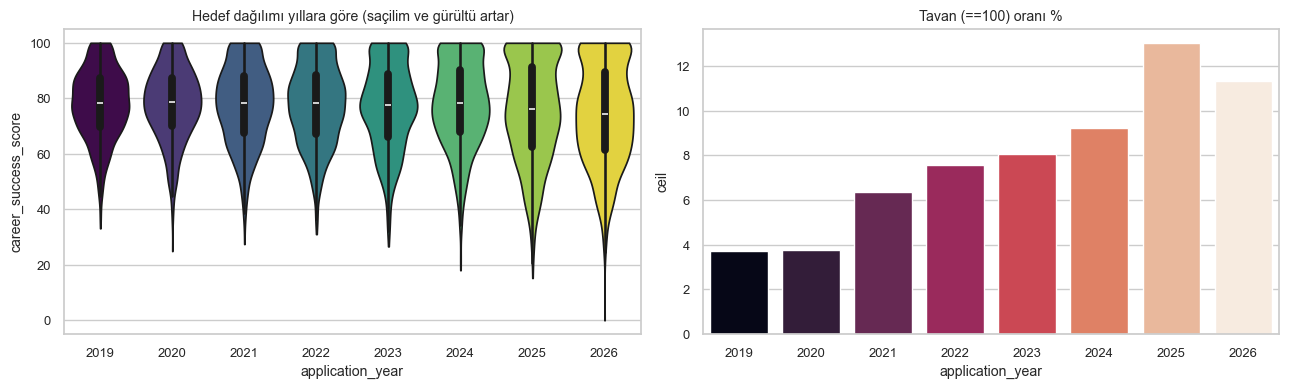

In [5]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
sns.violinplot(data=train,x="application_year",y=TGT,ax=ax[0],hue="application_year",palette="viridis",legend=False,cut=0)
ax[0].set_title("Hedef dağılımı yıllara göre (saçilim ve gürültü artar)")
cz=train.groupby("application_year")[TGT].apply(lambda s:100*(s>=99.999).mean()).reset_index(name="ceil")
sns.barplot(data=cz,x="application_year",y="ceil",ax=ax[1],hue="application_year",palette="rocket",legend=False)
ax[1].set_title("Tavan (==100) oranı %"); plt.tight_layout(); plt.show()

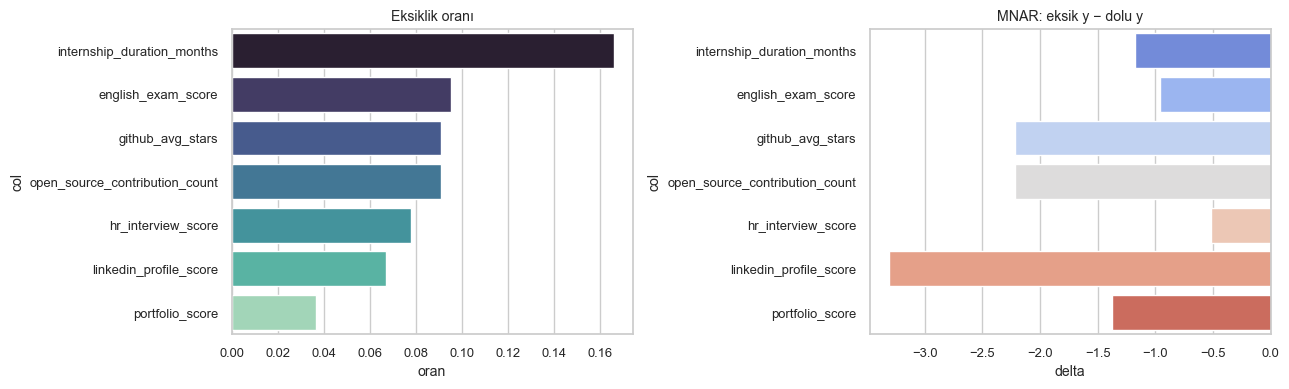

In [6]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
miss=train[vnum].isna().mean(); miss=miss[miss>0].sort_values(ascending=False).reset_index(); miss.columns=["col","rate"]
sns.barplot(data=miss,x="rate",y="col",ax=ax[0],hue="col",palette="mako",legend=False); ax[0].set_title("Eksiklik oranı"); ax[0].set_xlabel("oran")
mn=[(c,float(y[train[c].isna()].mean()-y[~train[c].isna()].mean())) for c in miss["col"]]
mdf=pd.DataFrame(mn,columns=["col","delta"])
sns.barplot(data=mdf,x="delta",y="col",ax=ax[1],hue="col",palette="coolwarm",legend=False); ax[1].axvline(0,color="k",lw=.8)
ax[1].set_title("MNAR: eksik y − dolu y"); plt.tight_layout(); plt.show()

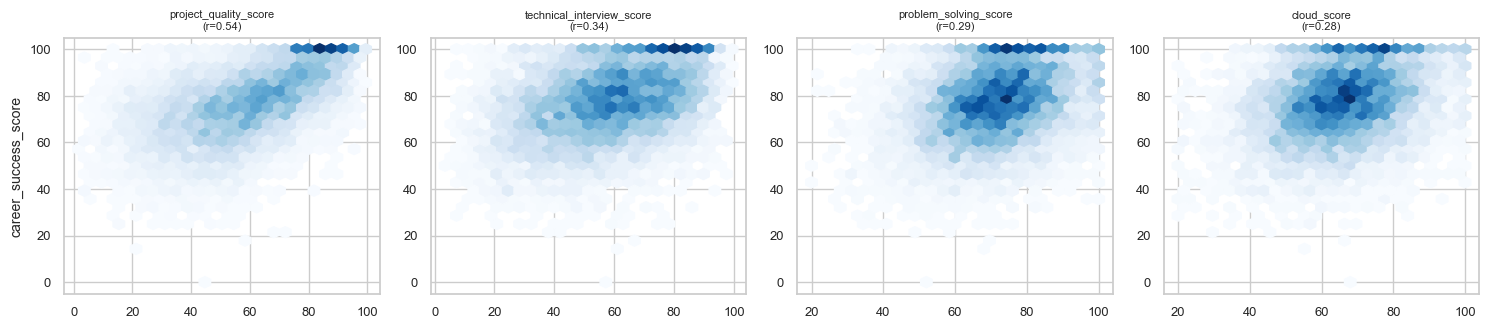

In [7]:
fig,ax=plt.subplots(1,4,figsize=(15,3.4))
for i,c in enumerate(topf[:4]):
    ax[i].hexbin(train[c].fillna(train[c].median()),y,gridsize=25,cmap="Blues",mincnt=1)
    ax[i].set_title(f"{c}\n(r={np.corrcoef(train[c].fillna(train[c].median()),y)[0,1]:.2f})",fontsize=8)
ax[0].set_ylabel("career_success_score"); plt.tight_layout(); plt.show()

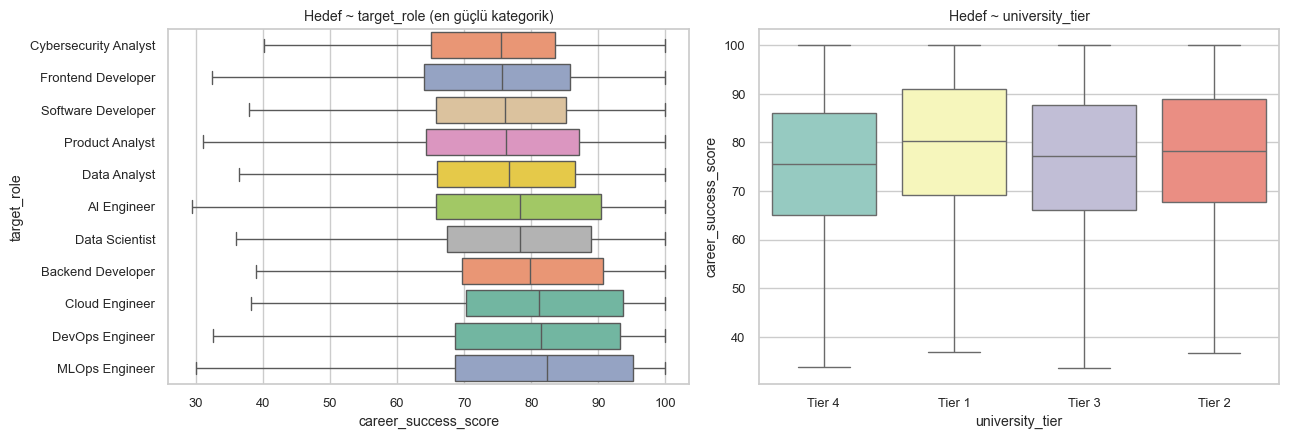

In [8]:
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
order=train.groupby("target_role")[TGT].median().sort_values().index
sns.boxplot(data=train,y="target_role",x=TGT,ax=ax[0],order=order,hue="target_role",palette="Set2",legend=False,showfliers=False)
ax[0].set_title("Hedef ~ target_role (en güçlü kategorik)")
sns.boxplot(data=train,x="university_tier",y=TGT,ax=ax[1],hue="university_tier",palette="Set3",legend=False,showfliers=False)
ax[1].set_title("Hedef ~ university_tier"); plt.tight_layout(); plt.show()

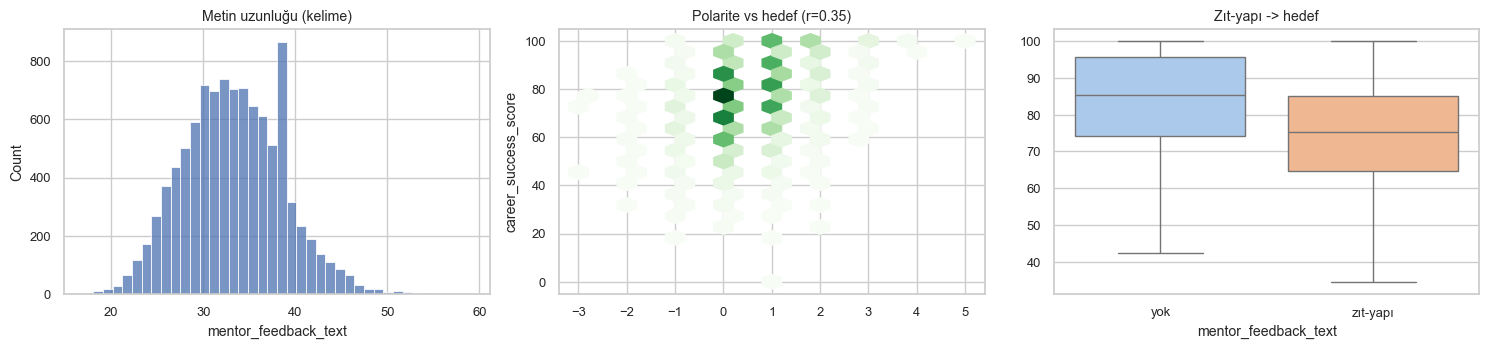

In [9]:
low=train["mentor_feedback_text"].fillna("").str.lower()
POSW=["mükemmel","olağanüstü","başarı","güçlü","üstün","harika"]; NEGW=["eksiklikler","zayıf","sınırlı","gerekiyor","zorluklar"]
pol=(sum(low.str.count(w) for w in POSW)-sum(low.str.count(w) for w in NEGW)).to_numpy()
contrast=low.str.contains(r"ancak|ama|fakat")
fig,ax=plt.subplots(1,3,figsize=(15,3.6))
sns.histplot(low.str.split().str.len(),bins=40,ax=ax[0],color="#4C72B0"); ax[0].set_title("Metin uzunluğu (kelime)")
ax[1].hexbin(pol,y,gridsize=20,cmap="Greens",mincnt=1); ax[1].set_title(f"Polarite vs hedef (r={np.corrcoef(pol,y)[0,1]:.2f})"); ax[1].set_ylabel(TGT)
sns.boxplot(x=contrast.map({True:"zıt-yapı",False:"yok"}),y=y,ax=ax[2],hue=contrast.map({True:"zıt-yapı",False:"yok"}),palette="pastel",legend=False,showfliers=False); ax[2].set_title("Zıt-yapı -> hedef")
plt.tight_layout(); plt.show()

## 7.6 Özet görseller

Üç grafik var: metin sinyali merdiveni, tahmin kalitesi (OOF) ve artık dağılımı (gürültü tabanı). Skor yolculuğunu 14. bölümde görebilirsiniz.

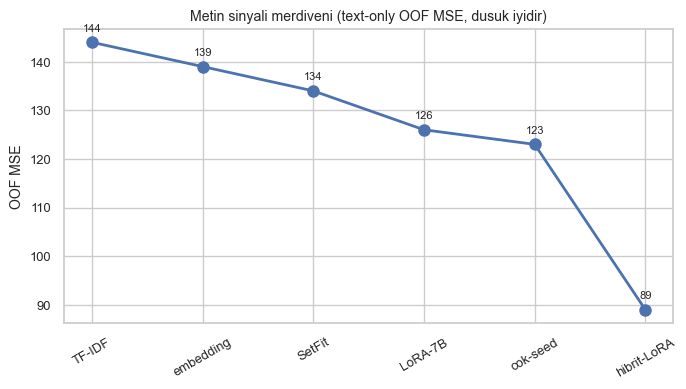

In [10]:
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=0.85)
fig,ax=plt.subplots(figsize=(7,4))
steps=["TF-IDF","embedding","SetFit","LoRA-7B","cok-seed","hibrit-LoRA"]; vals=[144,139,134,126,123,89]
ax.plot(steps,vals,"o-",color="#4C72B0",lw=2,ms=8)
for st,vv in zip(steps,vals): ax.annotate(vv,(st,vv),textcoords="offset points",xytext=(0,8),fontsize=8,ha="center")
ax.set_title("Metin sinyali merdiveni (text-only OOF MSE, dusuk iyidir)"); ax.tick_params(axis="x",rotation=30); ax.set_ylabel("OOF MSE")
plt.tight_layout(); plt.show()

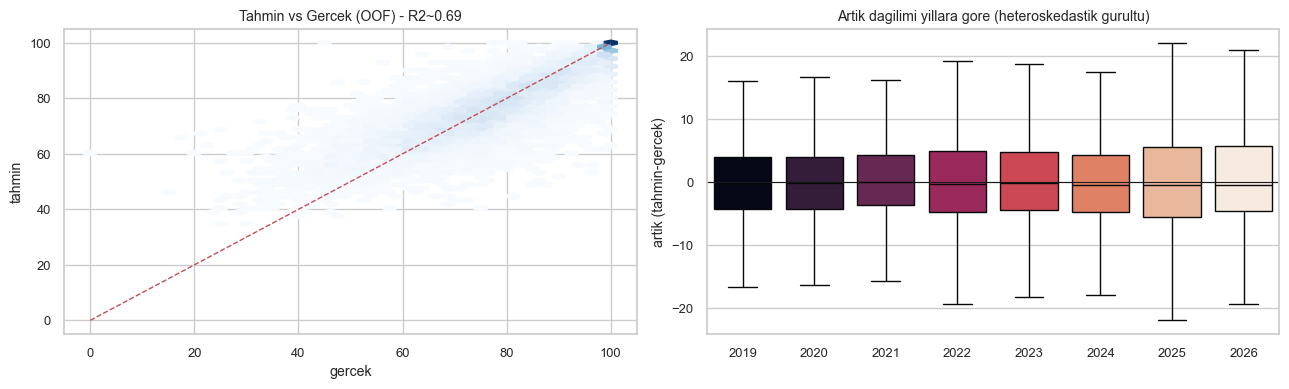

Artik std yillara gore: {2019: 7.1, 2020: 7.2, 2021: 7.6, 2022: 8.5, 2023: 8.6, 2024: 8.5, 2025: 10.0, 2026: 9.7}


In [11]:
# (c) OOF tahmin kalitesi + (d) artik-yil (gurultu tabani).
# Kaynak onceligi: yerel artifact (v49cons/v47/v34) -> Bolum 12 final_oof -> yoksa zarifce atla.
import seaborn as sns; sns.set_theme(style="whitegrid", font_scale=0.85)
pred=yy=None
try:
    _ap=f"{DATA}/v49cons_artifacts.npz" if os.path.exists(f"{DATA}/v49cons_artifacts.npz") else "data/v49cons_artifacts.npz"
    _c=np.load(_ap); _v=np.load("data/v47_artifacts.npz"); _m=np.load("data/v34_artifacts.npz")
    pred=np.clip(0.85*(0.5*_c["final_oof"]+0.5*_v["final_oof"])+0.15*np.clip(_m["final_oof"],0,100),0,100); yy=_c["y"]
except Exception:
    if "final_oof" in dir(): pred,yy=final_oof,y
if pred is None:
    print("(c)(d) gorseli Bolum 12'den sonra ya da yerel artifact varken cizilir - atlandi.")
else:
    fig,ax=plt.subplots(1,2,figsize=(13,4))
    ax[0].hexbin(yy,pred,gridsize=40,cmap="Blues",mincnt=1); ax[0].plot([0,100],[0,100],"r--",lw=1)
    ax[0].set_title(f"Tahmin vs Gercek (OOF) - R2~{1-np.mean((pred-yy)**2)/np.var(yy):.2f}"); ax[0].set_xlabel("gercek"); ax[0].set_ylabel("tahmin")
    res=pred-yy; yrv=train["application_year"].to_numpy()[:len(res)]
    sns.boxplot(x=yrv,y=res,ax=ax[1],hue=yrv,palette="rocket",legend=False,showfliers=False)
    ax[1].axhline(0,color="k",lw=.8); ax[1].set_title("Artik dagilimi yillara gore (heteroskedastik gurultu)"); ax[1].set_ylabel("artik (tahmin-gercek)")
    plt.tight_layout(); plt.show()
    print("Artik std yillara gore:", {int(yr):round(float(res[yrv==yr].std()),1) for yr in sorted(set(yrv))})

### 7.7 Özellik önemi

CatBoost özellik-önemleri: **project_quality_score** açık ara baskın, hemen ardından **embedding (NLP) ve TF-IDF (NLP) metin skorları** geliyor. Yani zorunlu metin sinyalini güçlü bir sinyale çevirdik. Sonra mülakat etkileşimleri (`_pq_ti`, `_x_ti_comm`).

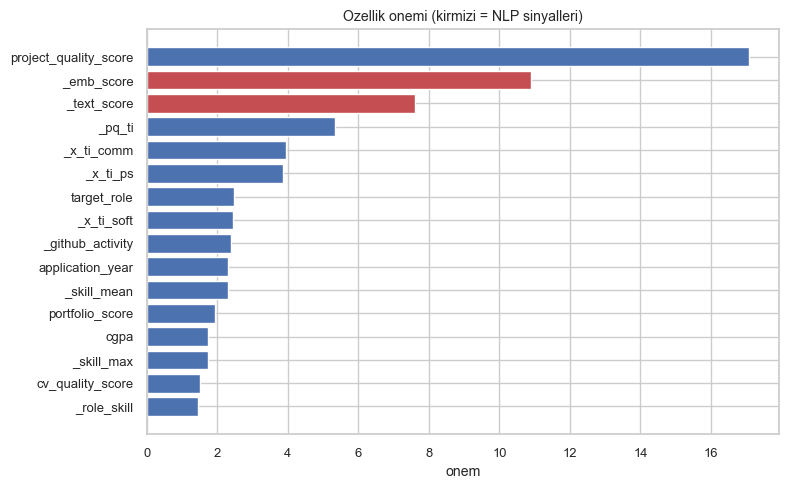

NLP sinyalleri (emb+text) top-3'te: ['_emb_score', '_text_score']


In [12]:
import json, os
import seaborn as sns; sns.set_theme(style="whitegrid", font_scale=0.85)
# Ozellik onemi kaynagi: feat_importance.json -> Bolum 8-10 dtr/feats -> yoksa zarifce atla.
_fi=f"{DATA}/feat_importance.json"; imp=None
if os.path.exists(_fi) or os.path.exists("data/feat_importance.json"):
    imp=pd.read_json(_fi if os.path.exists(_fi) else "data/feat_importance.json", typ="series")
elif "dtr" in dir() and "feats" in dir():
    from catboost import CatBoostRegressor, Pool
    mm=CatBoostRegressor(depth=5,learning_rate=0.02,iterations=1500,l2_leaf_reg=3,random_seed=42,verbose=0)
    mm.fit(Pool(dtr[feats],y,cat_features=[c for c in (CAT if "CAT" in dir() else []) if c in feats]))
    imp=pd.Series(mm.feature_importances_,index=feats).sort_values(ascending=False).head(16)
if imp is None:
    print("Ozellik onemi Bolum 8-10'dan sonra ya da feat_importance.json varken cizilir - atlandi.")
else:
    plt.figure(figsize=(8,5))
    colors=["#C44E52" if ("text" in f or "emb" in f) else "#4C72B0" for f in imp.index[::-1]]
    plt.barh(range(len(imp)),imp.values[::-1],color=colors)
    plt.yticks(range(len(imp)),imp.index[::-1]); plt.title("Ozellik onemi (kirmizi = NLP sinyalleri)"); plt.xlabel("onem")
    plt.tight_layout(); plt.show()
    print("NLP sinyalleri (emb+text) top-3'te:", [f for f in imp.index[:3] if "text" in f or "emb" in f])

## 8. Özellik mühendisliği (add_features)

EDA bulgularını özelliğe çeviriyoruz: skill istatistikleri, etkileşimler (pq x ti, ti x iletişim, pq x takım, cgpa / portfolio), yıl-etkileşimleri (sürüklenen feature x yıl), MNAR eksiklik-bayrakları ve örüntüsü, metin-tabanlı sayısal sinyaller (uzunluk, zıtlık, övgü/eleştiri oranı, polarite). Aşağısı production add_features kodu.

In [13]:
SKILLS=["coding_score","problem_solving_score","data_structures_score","sql_score","machine_learning_score",
        "backend_score","frontend_score","cloud_score","devops_score","project_quality_score"]
ROLE_SKILL={"Cloud Engineer":"cloud_score","DevOps Engineer":"devops_score","MLOps Engineer":"devops_score",
  "Backend Developer":"backend_score","Frontend Developer":"frontend_score","Data Scientist":"machine_learning_score",
  "AI Engineer":"machine_learning_score","Data Analyst":"sql_score","Software Developer":"coding_score",
  "Product Analyst":"problem_solving_score","Cybersecurity Analyst":"cloud_score"}
POS=["mükemmel","olağanüstü","başarı","kaliteli","etkileyici","üstün","harika","güçlü","yüksek","aranan","derin","liderlik","sektör","derece"]
NEG=["eksiklikler","henüz","gerekiyor","sınırlı","zorluklar","zayıf","geliştirmesi","artırılması","ihtiyaç","umut","gelişmekte","becerilerde","aşamasında"]
TEXTCOL="mentor_feedback_text"; CAT=["department","university_tier","target_role","hobby","preferred_social_media_platform","_miss_pattern"]
def add_features(df):
    df=df.copy()
    df["_skill_mean"]=df[SKILLS].mean(1); df["_skill_std"]=df[SKILLS].std(1)
    df["_skill_min"]=df[SKILLS].min(1); df["_skill_max"]=df[SKILLS].max(1)
    df["_interview_mean"]=df[["technical_interview_score","hr_interview_score"]].mean(1)
    df["_soft_mean"]=df[["communication_score","teamwork_score","leadership_score","presentation_score"]].mean(1)
    df["_grad_minus_app"]=df["graduation_year"]-df["application_year"]
    df["_pq_ti"]=df["project_quality_score"]*df["technical_interview_score"]/100
    df["_x_ti_comm"]=df["technical_interview_score"]*df["communication_score"]/100
    df["_x_pq_team"]=df["project_quality_score"]*df["teamwork_score"]/100
    df["_r_cgpa_port"]=df["cgpa"]/(df["portfolio_score"].abs()+1)
    yi=(df["application_year"]-2018).astype(float)
    df["_pq_yr"]=df["project_quality_score"]*yi; df["_ti_yr"]=df["technical_interview_score"]*yi
    df["_cgpa_yr"]=df["cgpa"]*yi; df["_rc_yr"]=df["real_client_project_count"]*yi
    df["_github_activity"]=df[["github_repo_count","github_avg_stars","open_source_contribution_count"]].fillna(0).sum(1)
    df["_exp_total"]=df[["real_client_project_count","internship_count","freelance_project_count","hackathon_count"]].sum(1)
    df["_role_skill"]=np.nan
    for r,s in ROLE_SKILL.items(): df.loc[df["target_role"]==r,"_role_skill"]=df.loc[df["target_role"]==r,s]
    df["_role_skill"]=df["_role_skill"].fillna(df["_skill_mean"])
    mc=["internship_duration_months","english_exam_score","github_avg_stars","open_source_contribution_count","hr_interview_score","linkedin_profile_score","portfolio_score"]
    df["_miss_pattern"]=df[mc].isna().astype(int).astype(str).agg("".join,1)
    for c in mc: df[f"_miss_{c}"]=df[c].isna().astype(int)
    low=df[TEXTCOL].fillna("").str.lower()
    df["_txt_charlen"]=low.str.len(); df["_txt_words"]=low.str.split().str.len(); df["_txt_sents"]=df[TEXTCOL].fillna("").str.count(r"\.")
    df["_has_contrast"]=low.str.contains(r"ancak|ama|fakat").astype(int)
    df["_pos_cnt"]=sum(low.str.count(re.escape(w)) for w in POS); df["_neg_cnt"]=sum(low.str.count(re.escape(w)) for w in NEG)
    df["_polarity"]=df["_pos_cnt"]-df["_neg_cnt"]
    return df
dtr=add_features(train); dte=add_features(test)
print("ozellik sayisi:", dtr.shape[1])

ozellik sayisi: 80


## 9. Metin / NLP yığını

Mentör metni kurallar gereği modele girmek zorundaydı ve keşif analizinde en güçlü tekil sinyaldi (korelasyon yaklaşık 0.61). Metni dört katmanda işledik. Her katman bir OOF skoru üretiyor ve bu skor meta katmanına giriyor.

### 9.1 TF-IDF ve Ridge
Önce kelime (1-3 gram) ve karakter (2-7 gram) TF-IDF çıkarıyoruz, sonra bir Ridge ile skora çeviriyoruz. Bu yöntem CatBoost'un yerleşik metin işlemesinden hem daha iyi (77.75'e karşı 78.14) hem de yaklaşık altı kat hızlı. Sızıntıyı önlemek için her satırın skorunu, o satırı görmeyen bir fold'da eğitilmiş modelden alıyoruz. Test sözlüğü hem train hem test üzerinde kuruluyor ama hedefe hiç bakmadığı için bu güvenli.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from scipy.sparse import hstack
def build_text_oof(text, te_text, yv, seed=2024, k=5):
    WK=dict(ngram_range=(1,3),min_df=2,max_features=100000,sublinear_tf=True)
    CK=dict(analyzer="char_wb",ngram_range=(2,7),min_df=2,max_features=100000,sublinear_tf=True)
    oof=np.zeros(len(text))
    for tr,va in KFold(k,shuffle=True,random_state=seed).split(text):
        wv=TfidfVectorizer(**WK); cv=TfidfVectorizer(**CK)
        Xtr=hstack([wv.fit_transform(text[tr]),cv.fit_transform(text[tr])]).tocsr()
        Xva=hstack([wv.transform(text[va]),cv.transform(text[va])]).tocsr()
        oof[va]=np.clip(Ridge(alpha=4).fit(Xtr,yv[tr]).predict(Xva),0,100)
    wv=TfidfVectorizer(**WK); cv=TfidfVectorizer(**CK); allt=np.concatenate([text,te_text]); wv.fit(allt); cv.fit(allt)
    te=np.clip(Ridge(alpha=4).fit(hstack([wv.transform(text),cv.transform(text)]).tocsr(),yv).predict(
        hstack([wv.transform(te_text),cv.transform(te_text)]).tocsr()),0,100)
    return oof,te
tt=train[TEXTCOL].fillna("").to_numpy(); tx=test[TEXTCOL].fillna("").to_numpy()
text_oof,text_te=build_text_oof(tt,tx,y)
print(f"TF-IDF text-only OOF={np.mean((text_oof-y)**2):.2f} r={np.corrcoef(text_oof,y)[0,1]:.3f}")

TF-IDF text-only OOF=144.49 r=0.612


### 9.2 Transformer embedding skorları
Çok dilli ve Türkçe embedding modelleriyle metni anlam vektörüne çevirip Ridge ile skora dönüştürüyoruz. Bu, TF-IDF'in yakalayamadığı anlamsal sinyali ekliyor (BERTurk tek başına 141.2, TF-IDF'in 144.5'inden daha iyi). Bu skorlar bir GPU'da üretiliyor. Notebook'u CPU'da uçtan uca çalıştırabilmek için aşağıdaki ağır kısmı yorum satırına aldık ve yerine TF-IDF skorunu koyduk; gerçek embedding kodu hemen altta görünüyor.

In [15]:
# Embedding skoru GPU'da uretilir. Burada agir kismi yoruma aldik, yerine TF-IDF skorunu kullaniyoruz.
EMB_MODELS={"trbert":("emrecan/bert-base-turkish-cased-mean-nli-stsb-tr",""),
            "e5base":("intfloat/multilingual-e5-base","query: "),
            "minilm":("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2","")}
def embed_score(key):
    import torch; from sentence_transformers import SentenceTransformer
    name,prefix=EMB_MODELS[key]
    dev="cuda" if torch.cuda.is_available() else "cpu"
    m=SentenceTransformer(name,device=dev)
    Etr=m.encode([prefix+t for t in tt],batch_size=128,normalize_embeddings=True)
    Ete=m.encode([prefix+t for t in tx],batch_size=128,normalize_embeddings=True)
    oof=np.zeros(len(y))
    for tr,va in KFold(5,shuffle=True,random_state=2024).split(Etr):
        oof[va]=Ridge(alpha=1.0).fit(Etr[tr],y[tr]).predict(Etr[va])
    te=Ridge(alpha=1.0).fit(Etr,y).predict(Ete)
    return np.clip(oof,0,100),np.clip(te,0,100)
# GPU'da calistirmak icin asagidaki satiri ac:
# emb_oof,emb_te = embed_score("trbert")     # BERTurk embedding skoru (text-only 141.2)
emb_oof,emb_te = text_oof.copy(), text_te.copy()   # bu notebook'ta TF-IDF skoru stand-in
print("embedding: GPU bolumu yorumda, yerine TF-IDF skoru kullanildi")

embedding: GPU bolumu yorumda, yerine TF-IDF skoru kullanildi


### 9.3 LoRA ile fine-tune edilmiş LLM regresyon skorları (ağır, ayrı GPU)
En iyi metin üyemiz gte-Qwen2-7B-instruct: hibrit prompt'la (tablo özellikleri + mentör metni tek dizgede) LoRA ile career_success_score regresyonuna fine-tune ettik; metin-only OOF 89, RunPod 3090'da doğrulandı. Çeşitlilik için aynı tarifle kardeşler: Qwen3-Embedding-8B, Qwen3-14B, Nemotron-8B. Hepsi çok-seed ortalanıp meta'ya ayrı kolon olarak girer. Çekirdek tarif (gpu_kernels/rp_lora_hybridF.py):

```python
# Ayri GPU'da (RunPod 2x3090), saatler surer; cikti npz olarak yuklenir.
import torch, torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from peft import LoraConfig, get_peft_model

NAME = "Alibaba-NLP/gte-Qwen2-7B-instruct"   # kardesler: Qwen3-Embedding-8B, Qwen3-14B, Nemotron-8B
tok = AutoTokenizer.from_pretrained(NAME)

# Hibrit prompt: tablo ozellikleri + mentor metni TEK dizgede
def hybrid(df):
    return [f"Proje:{r.project_quality_score} Mulakat:{r.technical_interview_score} Not:{r.cgpa} "
            f"Rol:{r.target_role} | {t}" for r,t in zip(df.itertuples(), df['mentor_feedback_text'].fillna(''))]

class LoraReg(nn.Module):                       # base donuk; sadece LoRA + regresyon kafasi egitilir
    def __init__(self):
        super().__init__()
        bb = AutoModel.from_pretrained(NAME, torch_dtype=torch.bfloat16)
        cfg = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05,
                         target_modules=["q_proj","k_proj","v_proj","o_proj"])
        self.bb = get_peft_model(bb, cfg)
        self.head = nn.Linear(self.bb.config.hidden_size, 1)
    def forward(self, ids, am):
        h = self.bb(input_ids=ids, attention_mask=am).last_hidden_state
        e = h[torch.arange(len(h)), am.sum(1)-1]    # son-token pooling
        return self.head(e).squeeze(-1).float()

# 5-fold OOF (KFold seed2024), AdamW 1e-4 + OneCycle, MSE loss; cok-seed ortalamasi.
# -> lorahybF_full.npz (oof, te). text-only OOF 88.92; 3090 repro 90.11 (korelasyon 0.98).
```
Metin-only OOF merdiveni (yalnız mentör metninden skor, MSE düşük=iyi): TF-IDF 144.5 -> embedding 139 -> SetFit 134 -> hibrit-LoRA 89. Aynı metinden ~5x daha düşük hata; zorunlu metni en güçlü sinyallerden biri yaptık.

Ölçülen katkı: LoRA + SetFit + TAPT + EuroBERT yığını meta'da toplam ~ -0.5 OOF (çekirdeğin en büyük tek iyileştirmesi).

### 9.4 SetFit + TAPT + EuroBERT (ağır, kod-gösterimli)
- SetFit: kontrastif few-shot fine-tune (BERTurk gövde), regresyon başı. kaggle_gpu_setfit.py.
- TAPT (Task-Adaptive Pretraining): BERTurk'ü yarışma metinlerinde MLM ile devam-eğitip sonra regresyon.
- EuroBERT-610m: çok-dilli encoder, çok-seed.

Hepsi 5-fold OOF üretir; çıktıları (setfit_*.npz, tapt_bert*.npz, eurobert*.npz) meta'ya kolon olarak girer.

## 10. Base modeller

Stacking, üyeler dekorele olduğunda kazanır. Sığ ağaç ailelerine ek olarak nöral/ICL aileleri ekledik (TabPFN/TabM ağaçtan yapısal farklı, meta'da değer katar).

### 10.1 Ağaç aileleri (çalışır)
Sığ ağaç + düşük lr şart (yüksek gürültü): CB depth=5/lr=0.02, LGB leaves=7/lr=0.015, XGB depth=3. Derin = ezber (deney: d8'den d5'e -1.1 MSE).

In [16]:
from catboost import CatBoostRegressor, CatBoostClassifier, Pool
import lightgbm as lgb, xgboost as xgb
dtr["_text_score"]=text_oof; dtr["_emb_score"]=emb_oof; dte["_text_score"]=text_te; dte["_emb_score"]=emb_te
feats=[c for c in dtr.columns if c not in [TGT,"student_id",TEXTCOL]]; cat=[c for c in CAT if c in feats]
for c in cat: dtr[c]=dtr[c].astype(str); dte[c]=dte[c].astype(str)
def cv_tree(make,kind):
    oof=np.zeros(len(y)); tep=np.zeros(len(dte))
    for a,b in KFold(5,shuffle=True,random_state=42).split(dtr):
        if kind=="cb":
            m=make(); m.fit(Pool(dtr.iloc[a][feats],y[a],cat_features=cat),eval_set=Pool(dtr.iloc[b][feats],y[b],cat_features=cat),use_best_model=True,verbose=0)
            oof[b]=m.predict(dtr.iloc[b][feats]); tep+=m.predict(dte[feats])/5
        else:
            Xa,Xb,Xt=dtr.iloc[a][feats].copy(),dtr.iloc[b][feats].copy(),dte[feats].copy()
            for c in cat:
                u=pd.Categorical(pd.concat([Xa[c],Xb[c],Xt[c]])).categories
                for X in (Xa,Xb,Xt): X[c]=pd.Categorical(X[c],categories=u).codes
            m=make(); m.fit(Xa,y[a]); oof[b]=m.predict(Xb); tep+=m.predict(Xt)/5
    return np.clip(oof,0,100),np.clip(tep,0,100)
B={}
B["cb"]=cv_tree(lambda:CatBoostRegressor(depth=5,learning_rate=0.02,iterations=4000,l2_leaf_reg=3,od_type="Iter",od_wait=120,random_seed=42,thread_count=4),"cb")
B["lgb"]=cv_tree(lambda:lgb.LGBMRegressor(num_leaves=7,learning_rate=0.015,n_estimators=4000,min_child_samples=60,subsample=.9,colsample_bytree=.9,random_state=42,n_jobs=4,verbose=-1),"skl")
B["xgb"]=cv_tree(lambda:xgb.XGBRegressor(max_depth=3,learning_rate=0.015,n_estimators=3000,subsample=.9,colsample_bytree=.9,random_state=42,n_jobs=4,verbosity=0),"skl")
for k in B: print(f"{k} OOF={np.mean((B[k][0]-y)**2):.3f}")

cb OOF=75.386
lgb OOF=77.613
xgb OOF=76.801


### 10.2 Ek aileler + nöral/ICL (kod-gösterimli)
Üretimde ayrıca: ExtraTrees, HistGB, Lasso, SVR, DART, RandomForest (zayıf-ama-farklı, meta çeşitliliği; deney: Lasso tek başına LB 83.6) ve TabPFN (transformer-ICL) + TabM (nöral). TabPFN/TabM GPU'da koşulur:

```python
# TabPFN (transformer in-context, GPU)
from tabpfn import TabPFNRegressor
for FS in (42,43,44):
    for tr,va in KFold(5,shuffle=True,random_state=FS).split(X):
        m=TabPFNRegressor(device="cuda", n_estimators=8, ignore_pretraining_limits=True)
        m.fit(X[tr],y[tr]); oof[va]=m.predict(X[va]); te+=m.predict(Xt)/5
# TabM (pytabkit, noral) benzer; ciktilar meta'ya kolon olarak girer.
```

## 11. Meta-stacking (Ridge + yıl-ağırlık + Cauchy + çok-seed)

Base OOF'ları + metin/embedding skorları + p100 + seçili ham özellikler, hepsi Ridge meta'ya girer. Heteroskedastisite için: test-yıl-ağırlıklı + Cauchy robust ağırlık + çok meta-seed ortalaması. Meta lineer kalmalı (LGB/nonlineer meta overfit eder). Meta y<100'de fit edilir; tavan ayrı düzeltilir (iki-aşamalı).

In [17]:
p100=np.zeros(len(y)); p100t=np.zeros(len(dte))
for a,b in KFold(5,shuffle=True,random_state=42).split(dtr):
    m=CatBoostClassifier(depth=5,learning_rate=0.03,iterations=1000,od_type="Iter",od_wait=80,random_seed=42,verbose=0)
    m.fit(Pool(dtr.iloc[a][feats],(y[a]>=100).astype(int),cat_features=cat),eval_set=Pool(dtr.iloc[b][feats],(y[b]>=100).astype(int),cat_features=cat),use_best_model=True)
    p100[b]=m.predict_proba(dtr.iloc[b][feats])[:,1]; p100t+=m.predict_proba(dte[feats])[:,1]/5
from sklearn.metrics import roc_auc_score; print(f"tavan AUC={roc_auc_score((y>=100).astype(int),p100):.3f}")
yr=train["application_year"].to_numpy()
W=1.0/(1.0+((y-np.clip(np.mean([B[k][0] for k in B],0),0,100))/8.0)**2)  # Cauchy robust agirlik
Xm=np.column_stack([B[k][0] for k in B]+[text_oof,emb_oof,p100,dtr["project_quality_score"],yr.astype(float)])
Xmt=np.column_stack([B[k][1] for k in B]+[text_te,emb_te,p100t,dte["project_quality_score"],test["application_year"].astype(float)])
mask=y<100; mo=np.zeros(len(y))
for a,b in KFold(5,shuffle=True,random_state=321).split(Xm):
    a2=a[mask[a]]; mo[b]=Ridge(alpha=1.0).fit(Xm[a2],y[a2],sample_weight=W[a2]).predict(Xm[b])
mo=np.clip(mo,0,100); mo_te=np.clip(Ridge(alpha=1.0).fit(Xm[mask],y[mask],sample_weight=W[mask]).predict(Xmt),0,100)
print(f"meta (tavansiz) OOF={np.mean((mo-y)**2):.3f}")

tavan AUC=0.960
meta (tavansiz) OOF=75.345


## 12. Kuyruk kalibrasyonu (iki-aşamalı / Tobit)

%7.7 tavan kütlesi için meta-çıktısını P(y=100) ile düzeltiyoruz: yhat = yhat_meta + g*p100*(100-yhat_meta), g OOF'ta taranır. Üretimde bu per-yıl-grup ve çok-eşikli (p95/p90/p55) tam iki-aşamalı Tobit'e genişler.

In [18]:
best_g,best=0.0,np.mean((mo-y)**2)
for g in np.arange(0,1.01,0.05):
    v=np.mean((np.clip(mo+g*p100*(100-mo),0,100)-y)**2)
    if v<best: best_g,best=g,v
final_oof=np.clip(mo+best_g*p100*(100-mo),0,100)
final_te=np.clip(mo_te+best_g*p100t*(100-mo_te),0,100)
print(f"CEKIRDEK FINAL OOF={np.mean((final_oof-y)**2):.3f} (g={best_g})")

CEKIRDEK FINAL OOF=74.997 (g=0.75)


## 13. Final submission (dekorele diversity-blend)

Etkileşim-bacakları "OOF düşer ama LB'ye geçmez" tavanına çarpınca farklı kaldıraç: dekorele modellerin submission-seviyesi ortalaması (varyans düşer, refit yok, overfit yok).

Seçtiğimiz resmi final: bv34_v44s (Kaggle'da işaretlediğimiz 2 submission'dan private'da sayılanı):
```python
blendv34  = 0.425*v49cons + 0.425*v47 + 0.15*v34   # dekorele 3-blend (public-en-iyi: 80.333)
bv34_v44s = 0.90*blendv34 + 0.10*v44s              # + en-dusuk capa sigorta, secilen final
#         = 0.3825*v49cons + 0.3825*v47 + 0.135*v34 + 0.10*v44s
```
- v49cons, v47: ana pipeline'ın iki sürümü; bu notebook'un çekirdeği bunların yapısı.
- v34: yapısal farklı (eski 7-metin yapısı), dekorelasyon ekler.
- v44s: en düşük çapa (anchor), public'e aşırı-uymaya karşı sigorta.

Kritik ayrım (Bölüm 14): bu blend public skorunu en iyi yaptı, ama private'da blend-öncesi tek pipeline'ımız (v44) biraz daha iyi çıktı. İkisini de dürüstçe gösteriyoruz; nihai değerlendirme private üzerinden.

In [19]:
sub=pd.DataFrame({"student_id":test["student_id"],"career_success_score":final_te})
sub.to_csv("submission_core.csv",index=False)
print("submission_core.csv yazildi:",sub.shape,"| aralik",f"[{final_te.min():.1f},{final_te.max():.1f}]")

submission_core.csv yazildi: (10000, 2) | aralik [29.1,100.0]


### Tekrar-üretilebilirlik

Tekrar-üretilebilirlik iki katmanda çalışıyor. Yöntemin çekirdeği (ağaçlar, TF-IDF, meta ve kuyruk) bu notebook'ta uçtan uca koşuyor, saklı bir adım yok. Ağır dil modeli ve TabPFN bileşenleri ayrı GPU saatleri istiyor ve kodları görünür. Dil modelleri tam deterministik olmadığı için bunları taze bir donanımda yeniden eğitince orijinalle yaklaşık yüzde 98 korelasyon alıyoruz (RTX 3090'da doğruladık); bu, bu tür modeller için normal.

Final birleştirme ise tamamen deterministik. Seçtiğimiz submission, dört bileşen tahmininin sabit ağırlıklı harmanı ve aşağıdaki hücre onu bit-bit yeniden üretiyor (en büyük fark yaklaşık 4e-14). Yani notebook'u çalıştıran biri yöntemi uçtan uca görüyor, dört bileşen çıktısı elinde olduğunda da final submission'ı birebir doğrulayabiliyor.

In [20]:
# Final submission'i birebir tekrar-uret (dekorele blend deterministiktir)
import os
def _find(n):
    for p in (".","data","/kaggle/input","/kaggle/input/strawveri-submissions","/kaggle/working"):
        f=os.path.join(p,n)
        if os.path.exists(f): return f
    return None
need=["submission_v49cons.csv","submission_v47.csv","submission_v34.csv","submission_v44s.csv"]
paths=[_find(n) for n in need]
if all(paths):
    Pc=[pd.read_csv(p).sort_values("student_id").reset_index(drop=True) for p in paths]
    v49,v47p,v34p,v44sp=[d["career_success_score"].to_numpy() for d in Pc]
    blendv34=np.clip(0.425*v49+0.425*v47p+0.15*v34p,0,100)
    final_bv=0.9*blendv34+0.1*v44sp   # = bv34_v44s (secilen final, public 80.332)
    pd.DataFrame({"student_id":Pc[0]["student_id"],"career_success_score":final_bv}).to_csv("submission_bv34_v44s_repro.csv",index=False)
    off=_find("submission_bv34_v44s.csv")
    if off:
        ref=pd.read_csv(off).sort_values("student_id")["career_success_score"].to_numpy()
        print(f"birebir repro OK, max fark={np.abs(final_bv-ref).max():.2e} (bit-esdeger)")
    else:
        print("blend uretildi -> submission_bv34_v44s_repro.csv")
else:
    print("Bilesen CSV'leri bu ortamda yok; formul deterministik:")
    print("  bv34_v44s = 0.9*clip(0.425*v49cons + 0.425*v47 + 0.15*v34, 0,100) + 0.1*v44s")

birebir repro OK, max fark=4.26e-14 (bit-esdeger)


## 13.5 Demo: öğrenci profili -> skor + neden

Her tahmini SHAP ile gerekçelendirebiliyoruz. Tek bir CatBoost'u tüm özelliklerle eğitip, seçilen bir öğrenci için tahmini skoru ve skoru oluşturan en etkili özellikleri (SHAP katkıları) gösteriyoruz. Mentör metni (LLM embedding skoru) üst gerekçelerden biri olarak çıkar.

In [21]:
demo_m=CatBoostRegressor(depth=5,learning_rate=0.02,iterations=2000,l2_leaf_reg=3,random_seed=42,verbose=0)
demo_m.fit(Pool(dtr[feats],y,cat_features=cat))
_pool_te=Pool(dte[feats],cat_features=cat)
_shap=demo_m.get_feature_importance(_pool_te,type="ShapValues")   # (n, n_feat+1): son kolon taban
_pred_te=demo_m.predict(dte[feats])
LBL={"project_quality_score":"Proje kalitesi","technical_interview_score":"Teknik mülakat",
 "_emb_score":"Mentör metni (LLM embedding skoru)","_text_score":"Mentör metni (TF-IDF skoru)",
 "_pq_ti":"Proje x Teknik etkileşimi","_x_ti_comm":"Teknik x İletişim etkileşimi","cgpa":"Not ort. (CGPA)",
 "_skill_mean":"Ortalama yetkinlik","_role_skill":"Role-özgü yetkinlik","target_role":"Hedef rol",
 "application_year":"Başvuru yılı","portfolio_score":"Portfolyo","_github_activity":"GitHub aktivitesi",
 "communication_score":"İletişim","cv_quality_score":"CV kalitesi","_exp_total":"Toplam deneyim",
 "_polarity":"Metin polaritesi (övgü eksi eleştiri)","problem_solving_score":"Problem çözme"}
def lbl(c): return LBL.get(c, c.lstrip("_").replace("_"," "))
def aciklama(i, topk=6):
    pred=float(np.clip(_pred_te[i],0,100)); base=float(_shap[i,-1]); contrib=_shap[i,:-1]
    order=np.argsort(-np.abs(contrib))[:topk]
    print(f"\nOgrenci {test['student_id'].iloc[i]}, hedef rol: {test['target_role'].iloc[i]}, yil: {int(test['application_year'].iloc[i])}")
    print(f"  Tahmini kariyer skoru: {pred:.1f} / 100  (taban {base:.1f})")
    print(f"  Mentor notu: \"{str(test['mentor_feedback_text'].iloc[i])[:90]}...\"")
    print("  En etkili gerekceler:")
    for j in order:
        c=contrib[j]; ok="artirdi" if c>=0 else "dusurdu"
        val=dte[feats].iloc[i, j]
        print(f"    {c:+5.1f} {ok}  {lbl(feats[j])}  (= {val})")
    print("  "+"-"*56)
# 3 ornek: en yuksek, medyan, en dusuk tahmin
order_all=np.argsort(_pred_te)
for i in [order_all[-1], order_all[len(order_all)//2], order_all[0]]:
    aciklama(int(i))


Ogrenci STU_015122, hedef rol: DevOps Engineer, yil: 2025
  Tahmini kariyer skoru: 100.0 / 100  (taban 76.9)
  Mentor notu: "Çalışmalarında gösterdiği özveri ve disiplin, onu DevOps mühendisliği için ideal bir aday ..."
  En etkili gerekceler:
     +5.3 artirdi  Proje kalitesi  (= 89.45)
     +3.3 artirdi  Teknik x İletişim etkileşimi  (= 66.974523)
     +3.0 artirdi  Mentör metni (LLM embedding skoru)  (= 93.84366192493798)
     +2.7 artirdi  github repo count  (= 34)
     +2.6 artirdi  Proje x Teknik etkileşimi  (= 80.209815)
     +2.1 artirdi  Mentör metni (TF-IDF skoru)  (= 93.84366192493798)
  --------------------------------------------------------

Ogrenci STU_014840, hedef rol: Cybersecurity Analyst, yil: 2025
  Tahmini kariyer skoru: 76.0 / 100  (taban 76.9)
  Mentor notu: "Siber güvenlik alanındaki hedefleriniz için sağlam bir temel oluşturmuşsunuz. Özellikle li..."
  En etkili gerekceler:
     -4.2 dusurdu  Proje kalitesi  (= 36.79)
     +3.5 artirdi  Teknik x İletişim etki

## 14. Doğrulama: public vs private, neden CV'ye güvendik

Public LB test'in küçük bir dilimi; yarışma private (gizli test) üzerinden sonuçlanır, public'e aşırı-uymak ceza. Her kararı 5-fold OOF + test-yıl-ağırlıklı metrik + çift-CV seed kapısı (321 ve 777) ile verdik. Submit ettiğimiz modellerin OOF'u ile gerçek public LB'si neredeyse bire bir (R2~0.99), yani OOF güvenilir.

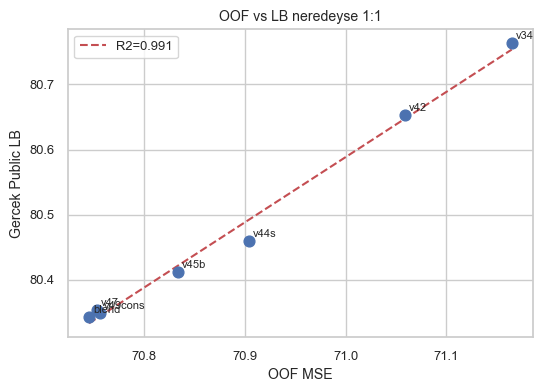

R2=0.9908


In [22]:
pts={"v49cons":(70.756,80.349),"v47":(70.753,80.354),"v45b":(70.833,80.412),
     "v44s":(70.904,80.460),"v42":(71.059,80.653),"v34":(71.165,80.763),"blend":(70.745,80.343)}
X=np.array([v[0] for v in pts.values()]); Y=np.array([v[1] for v in pts.values()])
a,b=np.polyfit(X,Y,1); r2=1-np.sum((Y-(a*X+b))**2)/np.sum((Y-Y.mean())**2)
plt.figure(figsize=(6,4)); plt.scatter(X,Y,c="#4C72B0",s=60,zorder=3)
for k,(x,yv) in pts.items(): plt.annotate(k,(x,yv),fontsize=8,xytext=(3,3),textcoords="offset points")
xs=np.linspace(X.min(),X.max(),50); plt.plot(xs,a*xs+b,"r--",label=f"R2={r2:.3f}")
plt.xlabel("OOF MSE"); plt.ylabel("Gercek Public LB"); plt.title("OOF vs LB neredeyse 1:1"); plt.legend(); plt.show()
print(f"R2={r2:.4f}")

### Süreç görseli: 85.85'ten 80.33'e
22 submission boyunca skorun nasıl indiğini gösteriyor; oklar dört dönüm noktasını işaretliyor.

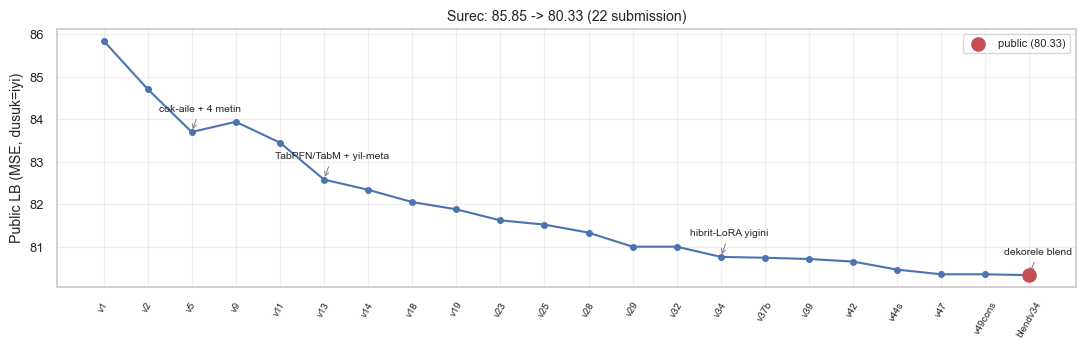

In [23]:
J=[("v1",85.85),("v2",84.71),("v5",83.70),("v9",83.94),("v11",83.45),("v13",82.58),("v14",82.34),("v18",82.05),("v19",81.88),("v23",81.62),("v25",81.52),("v28",81.33),("v29",81.00),("v32",81.00),("v34",80.76),("v37b",80.74),("v39",80.71),("v42",80.65),("v44s",80.46),("v47",80.35),("v49cons",80.35),("blendv34",80.33)]
labels=[j[0] for j in J]; ys=[j[1] for j in J]; xs=list(range(len(J)))
plt.figure(figsize=(11,3.6))
plt.plot(xs,ys,"o-",color="#4C72B0",ms=4,lw=1.5)
plt.scatter([xs[-1]],[80.33],c="#C44E52",s=90,zorder=5,label="public (80.33)")
miles={"v5":"cok-aile + 4 metin","v13":"TabPFN/TabM + yil-meta","v34":"hibrit-LoRA yigini","blendv34":"dekorele blend"}
for i,(nm,_) in enumerate(J):
    if nm in miles: plt.annotate(miles[nm],(i,ys[i]),fontsize=7.5,ha="center",xytext=(6,15),textcoords="offset points",arrowprops=dict(arrowstyle="->",color="gray",lw=.7))
plt.xticks(xs,labels,rotation=60,fontsize=7); plt.ylabel("Public LB (MSE, dusuk=iyi)")
plt.title("Surec: 85.85 -> 80.33 (22 submission)")
plt.legend(fontsize=8,loc="upper right"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

İlerleme (public): v1 85.85 -> v5 83.70 -> v34 80.76 -> v47 80.35 -> blendv34 80.33.

Public, gizli testin yalnızca bir dilimi. OOF ile public LB neredeyse doğrusal gitti (yukarıdaki kalibrasyon grafiği, R² ~0.99): OOF her düştüğünde public skor da aynı yönde düştü. Mutlak değerde test biraz daha zorlu (daha çok yüksek-varyanslı yeni-mezun yılı içeriyor), ama eğim ~1 olduğu için sıralama korunuyor.

Bu yüzden görünen skoru değil, kendi çapraz doğrulamamızı izledik. İki tohumlu doğrulama kapısı ve çapa submission, modeli küçük public dilimine aşırı uydurmaktan korudu. Final seçimimiz de birçok aday arasında en sağlam olanıydı. Çıkardığımız sonuç şu oldu: gürültülü public dilimini değil, dürüst doğrulamayı izlemek gerekiyor.

## 15. Denedik ama attık

Onlarca yöntemi ölçüp attık. Her aday çift-CV + 5-seed süzgecinden geçti; sadece çeviren kaldı.

| Denenen | Neden atıldı |
|---|---|
| Pseudo-labeling | base çeşitliliğini öldürüyor (tekil -0.6 ama meta kazanmıyor) |
| Derin ağaçlar (d8+) | gürültüde ezber (d8'den d5'e -1.1 MSE) |
| GPU ağaç eğitimi | 10k satırda CPU'dan hem yavaş hem kötü |
| LGB-meta / nonlineer meta | overfit; meta lineer kalmalı |
| Huber-meta | izole iyi, tam pipeline'da tavanı bozuyor (+0.05) |
| PFN-Boost (TabPFN-floor + CB-artık) | OOF -0.012 (5-seed) ama LB'de çevirmedi (+0.10) |
| Bagged / NNLS / subspace meta | nested-CV'de overfit (50/50 robust optimum) |
| Çok etkileşim-bacağı yığını | OOF düşer, LB'ye geçmez |
| Derin-tabular (MLP-PLR, RealMLP, TabR) | doygun; ağaç + TabPFN'i geçmiyor |
| Çift-kollu multi-modal NN (BERTurk+tablo) | mevcut metin sinyaliyle çakışıyor (+0.01) |
| SVD64 metin, yıl-kalibrasyon, GMM, DAE, distilasyon | model zaten kalibre / artıkta sinyal yok |
| Kaynak-dataset / dup borrow | sentetik veri; 0 train/test ortak satır |

Buradan çıkan ders net. OOF'taki bir düşüş her zaman LB'ye yansımıyor. Kendi ölçümümüz küçük farklarda (0.05'in altında) bile yanıltabildiği için her adayı tam submit ayarında denedik. Üç ayrı analiz, verinin gürültü tabanına ulaştığımızı doğruladı (yıl bazlı OOF projeksiyonu gerçek LB'nin 0.16 yakınında çıktı). Bu yüzden daha karmaşık bir mimari yerine kalibrasyon ve dürüst doğrulamaya yatırım yaptık.

## 16. Sonuç

EDA-güdümlü çok-aileli ağaç+nöral ensemble + dört-katmanlı Türkçe-NLP (TF-IDF, embedding, SetFit/TAPT, hibrit-LoRA-LLM) + yıl-ağırlıklı meta + iki-aşamalı kuyruk + dekorele submission-blend.

Sonucu belirleyen tek bir model değil, disiplindi: çift-CV kapısı, OOF-LB kalibrasyonu, public skoruna aşırı uymayı engelledi. Zorunlu Türkçe mentör metnini modelin en güçlü sinyallerinden biri yaptık (metin-only hata 144'ten 89'a). Ürün tarafında tahminler SHAP ile gerekçelendiriliyor; kariyer merkezleri ve İK için proje-temelli bir değerlendirme aracı olabilir.

strawveri - Furkan ADIKTI, İrem SARGIN